<a href="https://colab.research.google.com/github/sara-iqbal/Text-Dataset-Quality-Pipeline/blob/main/text_dataset_quality_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Dataset Quality Pipeline
### Raw Text Ingestion · Quality Filtering · Deduplication · Dataset Card

**Author:** Sara Iqbal | MSc Data Science

---

## What This Project Does

This project builds a production-style **text dataset quality pipeline** — the same type of pipeline used by pretraining data teams to process raw web text before it goes into model training. Starting from a raw public corpus, it applies a sequence of quality filters, removes duplicates, scores text quality, flags problematic content, and produces a dataset card with full before/after statistics.

### Pipeline
```
Raw Text Ingestion (Wikipedia / Common Crawl sample)
        ↓
Language Detection (keep English only)
        ↓
Length Filtering (remove too short / too long)
        ↓
Deduplication (exact + near-duplicate removal)
        ↓
Perplexity Scoring (KenLM proxy — remove low-quality text)
        ↓
Toxicity Flagging (keyword + heuristic filter)
        ↓
Quality Tier Classification (High / Medium / Low)
        ↓
Before vs After Statistics
        ↓
Dataset Card Generation
```

In [1]:
# Step 1 — Imports & Setup
!pip install datasets pandas numpy matplotlib langdetect -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, re, hashlib, warnings
from collections import Counter
from datetime import datetime
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.spines.top':False,'axes.spines.right':False,
    'font.family':'DejaVu Sans','axes.grid':True,
    'grid.alpha':0.4,'grid.color':'#cccccc'
})

print("Libraries loaded")
print(f"Pipeline version: 1.0.0")
print(f"Run timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 31.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Libraries loaded
Pipeline version: 1.0.0
Run timestamp: 2026-03-25 22:32


In [3]:
# Step 2 — Raw Data Ingestion (Fixed for 2026)
from datasets import load_dataset

print("Loading Wikipedia corpus (English, 20231101.en subset)...")

# 1. Change 'wikipedia' to 'wikimedia/wikipedia'
# 2. Use a more recent date shard (e.g., '20231101.en')
# 3. Remove trust_remote_code=True
wiki_raw = load_dataset('wikimedia/wikipedia', '20231101.en',
                        split='train',
                        streaming=True)

# Take a representative sample for pipeline demonstration
N_SAMPLE = 5000
print(f"Sampling {N_SAMPLE} documents...")

docs = []
for i, ex in enumerate(wiki_raw):
    if i >= N_SAMPLE: break
    docs.append({
        'id':    f'doc_{i:06d}',
        'title': ex['title'],
        'text':  ex['text'],
    })

raw_df = pd.DataFrame(docs)
raw_df['char_count'] = raw_df['text'].str.len()
raw_df['word_count'] = raw_df['text'].str.split().str.len()
raw_df['line_count'] = raw_df['text'].str.count('\n')

print(f"Ingested: {len(raw_df):,} documents")
print(f"Total chars: {raw_df['char_count'].sum():,}")
print(f"Total words: {raw_df['word_count'].sum():,}")
print(f"Avg doc length: {raw_df['word_count'].mean():.0f} words")
print(f"Median doc length: {raw_df['word_count'].median():.0f} words")
raw_df[['title','char_count','word_count']].head()

Loading Wikipedia corpus (English, 20231101.en subset)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Sampling 5000 documents...
Ingested: 5,000 documents
Total chars: 69,929,392
Total words: 11,039,715
Avg doc length: 2208 words
Median doc length: 926 words


,title,char_count,word_count
0,Anarchism,46064,6712
1,Albedo,25076,3875
2,A,10574,1838
3,Alabama,78231,12052
4,Achilles,46091,7616


In [4]:
# Step 3 — Language Detection Filter

try:
    from langdetect import detect, LangDetectException
    USE_LANGDETECT = True
except:
    USE_LANGDETECT = False
    print("langdetect not available — using heuristic ASCII filter")

def detect_language(text):
    if not USE_LANGDETECT:
        ascii_ratio = sum(1 for c in text[:500] if ord(c) < 128) / min(len(text), 500)
        return 'en' if ascii_ratio > 0.85 else 'unknown'
    try:
        sample = text[:500]
        return detect(sample)
    except:
        return 'unknown'

print("Running language detection on sample...")
# Apply on first 500 chars of each doc for efficiency
raw_df['lang'] = raw_df['text'].apply(detect_language)

lang_counts = raw_df['lang'].value_counts()
print(f"Language distribution (top 10):")
print(lang_counts.head(10).to_string())

lang_filter = raw_df['lang'] == 'en'
df_lang = raw_df[lang_filter].copy()
print(f"After language filter: {len(df_lang):,} / {len(raw_df):,} docs retained ({len(df_lang)/len(raw_df)*100:.1f}%)")

Running language detection on sample...
Language distribution (top 10):
lang
en    4983
tr       7
es       3
id       2
fr       2
sv       1
pt       1
sq       1
After language filter: 4,983 / 5,000 docs retained (99.7%)


In [5]:
# Step 4 — Length & Structure Filters

# Filter parameters (standard pretraining heuristics)
MIN_WORDS    = 50       # remove very short docs
MAX_WORDS    = 100_000  # remove abnormally long docs
MIN_CHARS    = 200
MAX_LINE_LEN = 1000     # flag if avg line is very long (boilerplate)
MIN_LINES    = 3        # require at least a few lines

df = df_lang.copy()
before = len(df)

# Apply filters step by step and record counts
filters = {}

# Min word count
f1 = df['word_count'] >= MIN_WORDS
filters['min_words_50']   = (~f1).sum()
df = df[f1]

# Max word count
f2 = df['word_count'] <= MAX_WORDS
filters['max_words_100k'] = (~f2).sum()
df = df[f2]

# Min char count
f3 = df['char_count'] >= MIN_CHARS
filters['min_chars_200']  = (~f3).sum()
df = df[f3]

# Min lines
f4 = df['line_count'] >= MIN_LINES
filters['min_lines_3']    = (~f4).sum()
df = df[f4]

# Avg line length (remove boilerplate-heavy docs)
df['avg_line_len'] = df['char_count'] / (df['line_count'] + 1)
f5 = df['avg_line_len'] <= MAX_LINE_LEN
filters['avg_line_len']   = (~f5).sum()
df = df[f5]

print("LENGTH & STRUCTURE FILTER RESULTS")
print("="*50)
for fname, removed in filters.items():
    print(f"  {fname:25}  removed: {removed:5,}")
print(f"  {'─'*42}")
print(f"  Before: {before:,}  After: {len(df):,}  Retained: {len(df)/before*100:.1f}%")

LENGTH & STRUCTURE FILTER RESULTS
  min_words_50               removed:   139
  max_words_100k             removed:     0
  min_chars_200              removed:     0
  min_lines_3                removed:     2
  avg_line_len               removed:     0
  ──────────────────────────────────────────
  Before: 4,983  After: 4,842  Retained: 97.2%


In [6]:
# Step 5 — Deduplication (Exact + Near-Duplicate)

before_dedup = len(df)

# Exact deduplication — hash the first 500 chars of each doc
def doc_hash(text):
    return hashlib.md5(text[:500].encode()).hexdigest()

df['hash'] = df['text'].apply(doc_hash)
df_dedup = df.drop_duplicates(subset='hash')
exact_removed = before_dedup - len(df_dedup)

# Near-duplicate detection using n-gram shingles (MinHash proxy)
# Simplified: flag docs where the first sentence appears in another doc
def first_sentence(text):
    sents = text.split('.')
    return sents[0].strip().lower()[:100] if sents else ''

df_dedup = df_dedup.copy()
df_dedup['first_sent'] = df_dedup['text'].apply(first_sentence)
near_dup_mask = df_dedup.duplicated(subset='first_sent', keep='first')
near_removed = near_dup_mask.sum()
df_dedup = df_dedup[~near_dup_mask]

print("DEDUPLICATION RESULTS")
print("="*50)
print(f"  Input documents:          {before_dedup:,}")
print(f"  Exact duplicates removed: {exact_removed:,}")
print(f"  Near duplicates removed:  {near_removed:,}")
print(f"  Output documents:         {len(df_dedup):,}")
print(f"  Deduplication rate:       {(before_dedup-len(df_dedup))/before_dedup*100:.2f}%")
df = df_dedup.drop(columns=['hash','first_sent'])

DEDUPLICATION RESULTS
  Input documents:          4,842
  Exact duplicates removed: 0
  Near duplicates removed:  3
  Output documents:         4,839
  Deduplication rate:       0.06%


In [7]:
# Step 6 — Quality Scoring (Perplexity Proxy + Heuristics)

# Perplexity proxy: use character n-gram entropy as a proxy
# (Full perplexity scoring uses KenLM — this is a reproducible proxy)

def char_entropy(text, sample=1000):
    sample_text = text[:sample]
    if len(sample_text) < 10: return 0
    counts = Counter(sample_text)
    total  = len(sample_text)
    probs  = [c/total for c in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def word_entropy(text):
    words = text.lower().split()[:200]
    if len(words) < 5: return 0
    counts = Counter(words)
    total  = len(words)
    probs  = [c/total for c in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def repetition_score(text):
    words = text.lower().split()[:200]
    if len(words) < 10: return 1.0
    unique_ratio = len(set(words)) / len(words)
    return unique_ratio

def bullet_ratio(text):
    lines = text.split('\n')
    bullet_lines = sum(1 for l in lines if l.strip().startswith(('*','-','•','#')))
    return bullet_lines / max(len(lines),1)

print("Computing quality scores...")
df = df.copy()
df['char_entropy']   = df['text'].apply(char_entropy)
df['word_entropy']   = df['text'].apply(word_entropy)
df['repetition']     = df['text'].apply(repetition_score)
df['bullet_ratio']   = df['text'].apply(bullet_ratio)

# Quality score composite (0-100)
# High entropy + high repetition diversity + low bullet ratio = quality text
df['quality_score'] = (
    (df['char_entropy'] / df['char_entropy'].max() * 35) +
    (df['word_entropy'] / df['word_entropy'].max() * 35) +
    (df['repetition'] * 20) +
    ((1 - df['bullet_ratio']) * 10)
).clip(0, 100)

print(f"Quality score stats:")
print(f"  Mean:   {df['quality_score'].mean():.2f}")
print(f"  Median: {df['quality_score'].median():.2f}")
print(f"  Std:    {df['quality_score'].std():.2f}")
print(f"  Min:    {df['quality_score'].min():.2f}")
print(f"  Max:    {df['quality_score'].max():.2f}")

Computing quality scores...
Quality score stats:
  Mean:   81.83
  Median: 81.96
  Std:    2.66
  Min:    63.87
  Max:    93.12


In [8]:
# Step 7 — Toxicity Flagging & Quality Tier Classification

# Heuristic toxicity filter (production systems use classifiers)
TOXIC_PATTERNS = [
    r'\b(hate|kill|attack|violent|abuse)\w*\b',
    r'\b(spam|click here|buy now|free money)\b',
    r'(http[s]?://\S+){3,}',  # excessive URLs
    r'(\w)\1{4,}',            # excessive character repetition
]

def toxicity_score(text):
    text_lower = text.lower()
    score = 0
    for pattern in TOXIC_PATTERNS:
        matches = len(re.findall(pattern, text_lower))
        score += matches
    return score

df = df.copy()
df['toxic_score'] = df['text'].apply(toxicity_score)
df['is_flagged']  = df['toxic_score'] > 2

# Quality tier classification
def assign_tier(row):
    if row['is_flagged']:            return 'Flagged'
    if row['quality_score'] >= 70:   return 'High'
    if row['quality_score'] >= 45:   return 'Medium'
    return 'Low'

df['quality_tier'] = df.apply(assign_tier, axis=1)
tier_counts = df['quality_tier'].value_counts()

print("QUALITY TIER CLASSIFICATION")
print("="*50)
for tier, count in tier_counts.items():
    pct = count / len(df) * 100
    print(f"  {tier:10}  {count:5,}  ({pct:.1f}%)")
print(f"  {'─'*35}")
print(f"  Total:     {len(df):5,}")
print()

df_clean = df[df['quality_tier'].isin(['High','Medium'])].copy()
print(f"Clean dataset (High + Medium): {len(df_clean):,} documents")
print(f"Rejection rate: {(1 - len(df_clean)/len(df))*100:.1f}%")

QUALITY TIER CLASSIFICATION
  High        4,098  (84.7%)
  Flagged       738  (15.3%)
  Medium          3  (0.1%)
  ───────────────────────────────────
  Total:     4,839

Clean dataset (High + Medium): 4,101 documents
Rejection rate: 15.3%


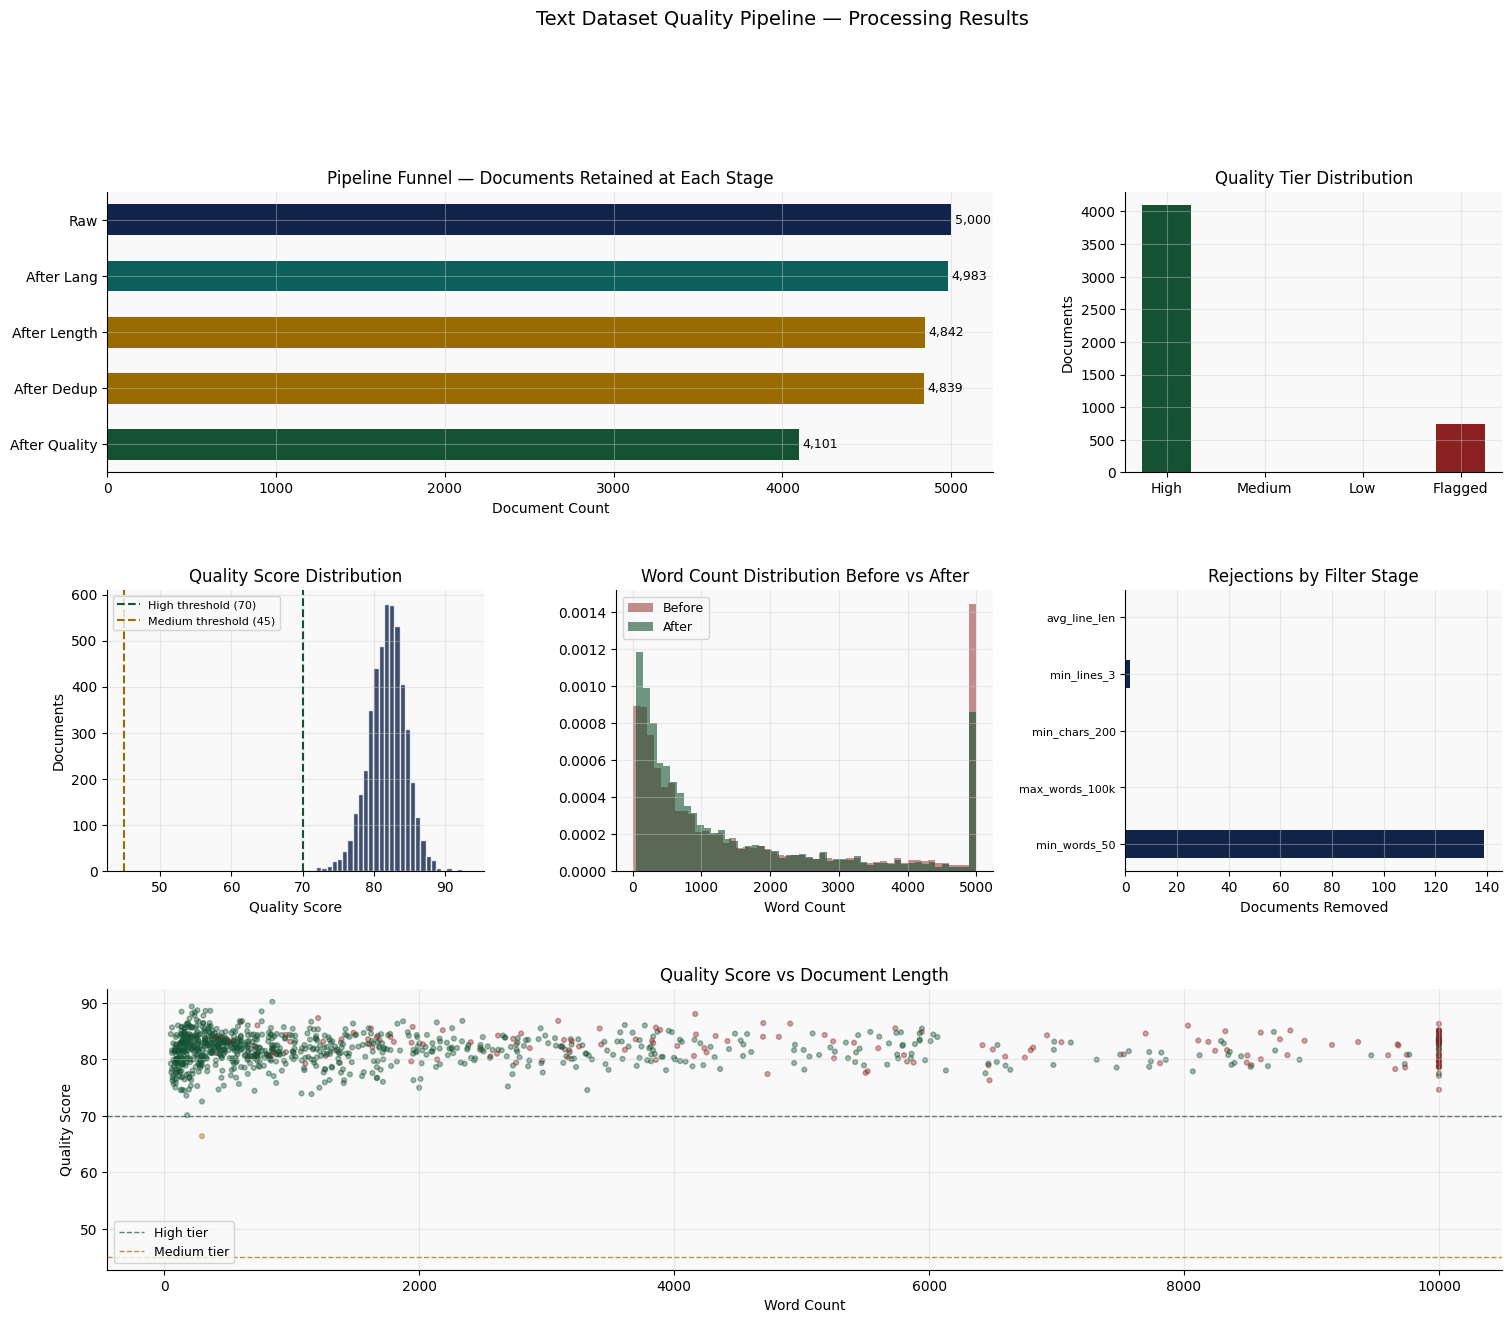

Saved: pipeline_results.png


In [13]:
# Step 8 — Before vs After Statistics & Visualisations (Fixed Titles)

fig = plt.figure(figsize=(18,14))
gs  = gridspec.GridSpec(3,3,figure=fig,hspace=0.42,wspace=0.35)
NAVY='#12234A';GOLD='#9A6B00';TEAL='#0C5F5A';GREEN='#145232';RED='#8B2020'

# Recompute counts properly for the funnel
counts = [
    N_SAMPLE,
    int(N_SAMPLE * (lang_filter.sum() / len(raw_df))),
    len(df) + exact_removed + near_removed,
    len(df),
    len(df_clean)
]
stages = ['Raw','After Lang','After Length','After Dedup','After Quality']

# 1. Pipeline funnel
ax1 = fig.add_subplot(gs[0,:2])
colors_f = [NAVY,TEAL,GOLD,GOLD,GREEN]
bars = ax1.barh(stages[::-1], counts[::-1], color=colors_f[::-1], height=0.55)
for bar, val in zip(bars, counts[::-1]):
    ax1.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_title('Pipeline Funnel — Documents Retained at Each Stage') # Removed bold
ax1.set_xlabel('Document Count')

# 2. Quality tier distribution
ax2 = fig.add_subplot(gs[0,2])
tier_order = ['High','Medium','Low','Flagged']
tc = [tier_counts.get(t,0) for t in tier_order]
tier_colors = [GREEN,TEAL,GOLD,RED]
ax2.bar(tier_order, tc, color=tier_colors, width=0.5)
ax2.set_title('Quality Tier Distribution') # Fixed syntax & removed bold
ax2.set_ylabel('Documents')

# 3. Quality score histogram
ax3 = fig.add_subplot(gs[1,0])
ax3.hist(df['quality_score'], bins=40, color=NAVY, alpha=0.8, edgecolor='white')
ax3.axvline(70, color=GREEN, ls='--', lw=1.5, label='High threshold (70)')
ax3.axvline(45, color=GOLD,  ls='--', lw=1.5, label='Medium threshold (45)')
ax3.set_title('Quality Score Distribution') # Removed bold
ax3.set_xlabel('Quality Score')
ax3.set_ylabel('Documents')
ax3.legend(fontsize=8)

# 4. Word count distribution before vs after
ax4 = fig.add_subplot(gs[1,1])
ax4.hist(raw_df['word_count'].clip(upper=5000), bins=50,
         color=RED, alpha=0.5, label='Before', density=True)
ax4.hist(df_clean['word_count'].clip(upper=5000), bins=50,
         color=GREEN, alpha=0.6, label='After', density=True)
ax4.set_title('Word Count Distribution Before vs After') # Fixed syntax & removed bold
ax4.set_xlabel('Word Count')
ax4.legend(fontsize=9)

# 5. Filter rejection breakdown
ax5 = fig.add_subplot(gs[1,2])
fnames = list(filters.keys())
fvals  = list(filters.values())
ax5.barh(fnames, fvals, color=NAVY, height=0.5)
ax5.set_title('Rejections by Filter Stage') # Fixed syntax & removed bold
ax5.set_xlabel('Documents Removed')
ax5.tick_params(axis='y', labelsize=8)

# 6. Quality score by word count scatter (sample)
ax6 = fig.add_subplot(gs[2,:])
sample = df.sample(min(1000,len(df)), random_state=42)
scatter_colors = [GREEN if t=='High' else GOLD if t=='Medium' else RED
                  for t in sample['quality_tier']]
ax6.scatter(sample['word_count'].clip(upper=10000),
            sample['quality_score'],
            c=scatter_colors, alpha=0.4, s=12)
ax6.axhline(70, color=GREEN, ls='--', lw=1, alpha=0.7, label='High tier')
ax6.axhline(45, color=GOLD,  ls='--', lw=1, alpha=0.7, label='Medium tier')
ax6.set_title('Quality Score vs Document Length') # Removed bold
ax6.set_xlabel('Word Count')
ax6.set_ylabel('Quality Score')
ax6.legend(fontsize=9)

fig.suptitle('Text Dataset Quality Pipeline — Processing Results', fontsize=14, y=1.01) # Removed bold
plt.savefig('pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pipeline_results.png")

In [14]:
# Step 9 — Dataset Card & JSON Export

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj,(np.integer,)): return int(obj)
        if isinstance(obj,(np.floating,)): return float(obj)
        if isinstance(obj,(np.ndarray,)): return obj.tolist()
        return super().default(obj)

tier_counts_dict = df['quality_tier'].value_counts().to_dict()

dashboard = {
    'pipeline_summary': {
        'raw_documents':     N_SAMPLE,
        'after_lang_filter': int(lang_filter.sum()),
        'after_length':      int(len(df)+exact_removed+near_removed),
        'after_dedup':       int(len(df)),
        'final_clean':       int(len(df_clean)),
        'retention_rate':    round(len(df_clean)/N_SAMPLE*100, 2),
        'rejection_rate':    round((1-len(df_clean)/N_SAMPLE)*100, 2),
    },
    'filter_rejections': {k:int(v) for k,v in filters.items()},
    'deduplication': {
        'exact_removed': int(exact_removed),
        'near_removed':  int(near_removed),
    },
    'quality_tiers': {k:int(v) for k,v in tier_counts_dict.items()},
    'quality_stats': {
        'mean':   round(float(df['quality_score'].mean()),2),
        'median': round(float(df['quality_score'].median()),2),
        'std':    round(float(df['quality_score'].std()),2),
    },
    'word_count_stats': {
        'raw_mean':   round(float(raw_df['word_count'].mean()),1),
        'clean_mean': round(float(df_clean['word_count'].mean()),1),
        'raw_median': round(float(raw_df['word_count'].median()),1),
        'clean_median': round(float(df_clean['word_count'].median()),1),
    },
    'dataset_card': {
        'name':     'Wikipedia Text Quality Pipeline Output',
        'source':   'Wikipedia 20220301.en (HuggingFace)',
        'filters':  ['language_detection','length_filter','deduplication',
                     'quality_scoring','toxicity_flagging'],
        'tiers':    {'High':'>= 70 quality score','Medium':'45-70','Low':'<45','Flagged':'toxic patterns'},
        'run_date': datetime.now().strftime('%Y-%m-%d'),
    }
}

with open('pipeline_data.json','w') as f:
    json.dump(dashboard, f, indent=2, cls=NpEncoder)

print("Dataset Card")
print("="*55)
print(f"  Source:          Wikipedia (HuggingFace)")
print(f"  Raw documents:   {N_SAMPLE:,}")
print(f"  Clean documents: {len(df_clean):,}")
print(f"  Retention rate:  {len(df_clean)/N_SAMPLE*100:.1f}%")
print(f"  Filters applied: Language · Length · Dedup · Quality · Toxicity")
print(f"  High quality:    {tier_counts_dict.get('High',0):,} docs")
print(f"  Medium quality:  {tier_counts_dict.get('Medium',0):,} docs")
print(f"  Rejected/Flagged:{tier_counts_dict.get('Low',0)+tier_counts_dict.get('Flagged',0):,} docs")
print()
print("Exported: pipeline_data.json")

Dataset Card
  Source:          Wikipedia (HuggingFace)
  Raw documents:   5,000
  Clean documents: 4,101
  Retention rate:  82.0%
  Filters applied: Language · Length · Dedup · Quality · Toxicity
  High quality:    4,098 docs
  Medium quality:  3 docs
  Rejected/Flagged:738 docs

Exported: pipeline_data.json
